## Raport 2
Adam Freń, Karol Garbaczewski

In [3]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

### 1.
Z populacji generalnej o rozkładzie normalnym $N (\mu, \sigma = 0.2)$ pobrano próbę (dane dołączone do
listy). Dla $\alpha$ = 0.05 zweryfikuj hipotezy
+ $\mu \ne 1.5$
+  $\mu < 1.5$
+  $\mu > 1.5$ 

Narysuj odpowiednie obszary kytyczne i wyznacz p-wartości dla każdej z powyższych hipotez. Odpo-
wiedz na pytanie co stanie się kiedy zwiększymy bądź zmniejszymy poziom ufności.
Przyjmujemy że hipoteza zerowa tutaj jest równa $H_0: \mu = 1.5$

In [5]:
plik=open("./lista7zad1.txt",'r')
p=plik.read()
p=p.split(",")
N=1_000_000
for i in range(len(p)):
    p[i] = float(p[i])
sigma=0.2
x_dash=np.mean(p)   
Z=x_dash
alpha=0.05
left_crit=(-1)*scipy.stats.norm.ppf(q=1-alpha,loc=0,scale=1)
right_crit=scipy.stats.norm.ppf(q=1-alpha,loc=0,scale=1)
both_crit=scipy.stats.norm.ppf(q=1-(alpha/2),loc=0,scale=1)
mu=1.5
Z=(Z-mu)/(sigma/np.sqrt(len(p)))
t=np.linspace(-3,3,500)

Dla hipotezy alternatywnej $\mu \ne 1.5$ (test obustronny)

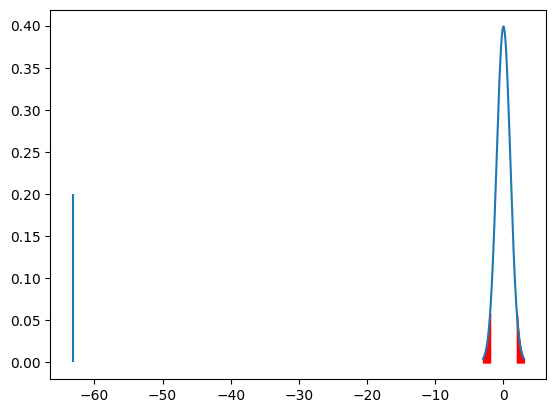

Wartość p: 0.0


In [18]:
pdf_draw=[scipy.stats.norm.pdf(x) for x in t]
plt.plot(t,pdf_draw)
plt.fill_between(x=t,y1=pdf_draw,where = (t<-both_crit),color='r')
plt.fill_between(x=t,y1=pdf_draw,where = (t>both_crit),color='r')
plt.vlines(Z,0,0.2)
plt.show()
p_value=2*scipy.stats.norm.sf(abs(Z))
print("Wartość p:",p_value)

Statystyka Z wpada w obszar krytyczny,więc odrzucamy hipotezę zerową i nie ma podstaw do odrzucenia hipotezę alternatywną.

Dla hipotezy alternatywnej $\mu < 1.5$ (test lewostronny)

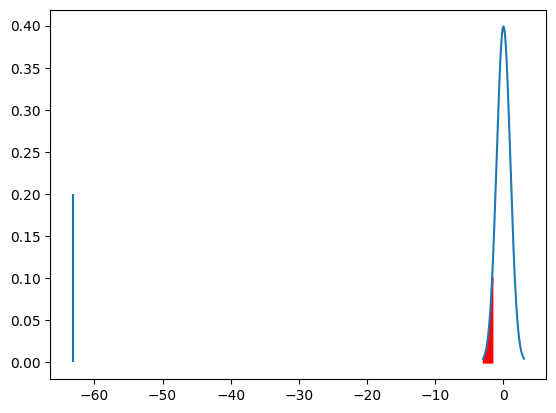

Wartość p: 0.0


In [45]:
plt.plot(t,pdf_draw)
plt.fill_between(x=t,y1=pdf_draw,where = (t<left_crit),color='r')
plt.vlines(Z,0,0.2)
plt.show()
p_value=scipy.stats.norm.cdf(Z)
print("Wartość p:",p_value)

Statystyka Z wpada w obszar krytyczny,więc odrzucamy hipotezę zerową i możemy przyjąć hipotezę alternatywną.

Dla hipotezy alternatywnej $\mu > 1.5$ (test prawostronny)

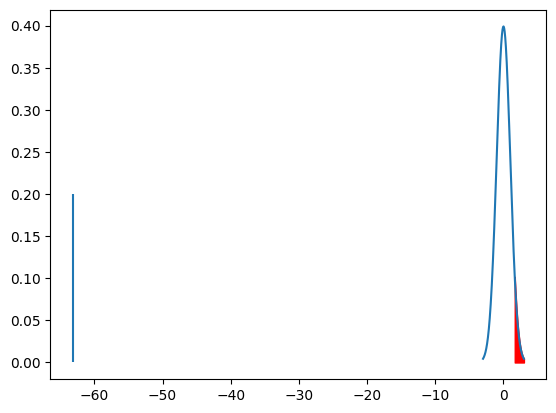

Wartość p: 1.0


In [46]:
plt.plot(t,pdf_draw)
plt.fill_between(x=t,y1=pdf_draw,where = (t>right_crit),color='r')
plt.vlines(Z,0,0.2)
plt.show()
p_value=scipy.stats.norm.sf(Z)
print("Wartość p:",p_value)

Statystyka Z wpada w obszar krytyczny,więc odrzucamy hipotezę alternatywną i możemy przyjąć hipotezę zerową.

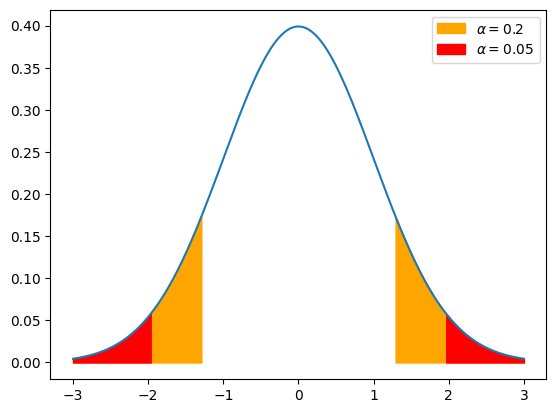

In [47]:
plt.plot(t,pdf_draw)
alpha=0.2
both_crit=scipy.stats.norm.ppf(q=1-(alpha/2),loc=0,scale=1)
plt.fill_between(x=t,y1=pdf_draw,where = (t<-both_crit),color='orange',label=r"$\alpha = 0.2$")
plt.fill_between(x=t,y1=pdf_draw,where = (t>both_crit),color='orange')
alpha=0.05
both_crit=scipy.stats.norm.ppf(q=1-(alpha/2),loc=0,scale=1)
plt.fill_between(x=t,y1=pdf_draw,where = (t<-both_crit),color='r',label=r"$\alpha = 0.05$")
plt.fill_between(x=t,y1=pdf_draw,where = (t>both_crit),color='r')
plt.legend()
plt.show()

Z wykresu widać że wraz ze wzrostem $\alpha$ obszar krytyczny się zwiększa.Dokładnie takie samo zachowanie obserwujemy w testach jednostronnych

### 2.


### 3.
Dla hipotez z zadań 1-2 wyznacz symulacyjnie prawdopodobieństwa popełnienia błędów I i II rodzaju.
Sprawdź moce testów.

In [101]:
mu=1.5
sigma=0.2
Z_vect=[]
alpha=0.05
N=1000
for i in range(10_000):
    T=np.random.normal(mu,sigma,N)
    Z=np.mean(T)-mu
    Z=Z/((sigma)/(np.sqrt(N)))
    Z_vect.append(Z)
left_probab=0
right_probab=0
both_probab=0    
counter=0
for z in Z_vect:

    if scipy.stats.norm.cdf(z)<alpha:
        left_probab+=1
    if scipy.stats.norm.sf(z)<alpha:
        right_probab+=1
    if 2*scipy.stats.norm.sf(abs(z))<alpha:
        both_probab+=1
    counter+=1
print("Prawdopodobieństwo błędu I rodzaju:")
print("Test lewostronny:",left_probab/counter)
print("Test prawostronny:",right_probab/counter)
print("Test obustronny:",both_probab/counter)


Prawdopodobieństwo błędu I rodzaju:
Test lewostronny: 0.049
Test prawostronny: 0.0491
Test obustronny: 0.0485


Dla podanego przykładu (N=1000) prawdopodobieństwo błędu 1 rodzaju wynosi 
+ dla testu lewostronnego: $\sim$ 0.05
+ dla testu prawostronnego: $\sim$  0.05
+ dla test obustronnego: $\sim$  0.05
Prawdopodobieństwo błędu jest tak niskie ponieważ wariancja rozkładu jest niska

In [111]:
M=100_000
mu=1.5
R=np.random.uniform(-0.3,0.3,M)
mu_0=[mu]
sigma=0.2
Z_vect=[]
alpha=0.05
N=1000
for i in range(M):
    T=np.random.normal(mu,sigma,N)
    Z=np.mean(T)-mu+R[i]
    Z=Z/((sigma)/(np.sqrt(N)))
    Z_vect.append(Z)
left_probab=0
right_probab=0
both_probab=0    
counter=0
for i in range(len(Z_vect)):
    if scipy.stats.norm.cdf(Z_vect[i])>alpha:
            left_probab+=1
    if scipy.stats.norm.sf(Z_vect[i])>alpha:
            right_probab+=1
    if 2*scipy.stats.norm.sf(abs(Z_vect[i]))>alpha:
        both_probab+=1
    counter+=1
print("Prawdopodobieństwo błędu II rodzaju:")
print("Test lewostronny:",left_probab/counter)
print("Test prawostronny:",right_probab/counter)
print("Test obustronny:",both_probab/counter)


Prawdopodobieństwo błędu II rodzaju:
Test lewostronny: 0.51536
Test prawostronny: 0.51905
Test obustronny: 0.04149


Dla podanego przykładu (N=1000) prawdopodobieństwo błędu 2 rodzaju wynosi 
+ dla testu lewostronnego: $\sim$ 0.5
+ dla testu prawostronnego: $\sim$  0.5
+ dla test obustronnego: $\sim$  0.05

# v Do Przepisania inaczej !!!!

prawdopodobieństwa dla lewostronnego i prawostronnego są tak wysokie ponieważ to, że test nie wpada w "połowiczny" przedział ufności nie oznacza, że jest bliski zadanej średniej

# ^ Do Przepisania inaczej !!!!